# Dataset 2 Analysis: KaraOne


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, Markdown, display

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'scripts' / 'eeg_dataset_analysis_lib.py').exists():
            return candidate
    raise RuntimeError('Could not locate project root containing scripts/eeg_dataset_analysis_lib.py')

PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))
from eeg_dataset_analysis_lib import analyze_karaone


In [2]:
bundle = analyze_karaone()
summary = bundle.summary
assets = bundle.assets
summary['dataset_name'], summary['downloaded_archive_count']

Reading 0 ... 16572  =      0.000 ...    16.572 secs...


('KaraOne', 14)

## 一、数据集整体概览

In [3]:
archive_df = pd.DataFrame(summary['archive_rows'], columns=['subject_archive', 'size_gb'])
display(archive_df)
display(Markdown(f"- representative subject: `{summary['representative_subject']}`"))
display(Markdown(f"- sampling rate: `{summary['sampling_rate_hz']}` Hz"))
display(Markdown(f"- raw duration: `{summary['raw_duration_sec'] / 60:.2f}` minutes"))


,subject_archive,size_gb
0,MM05,2.04
1,MM08,2.24
2,MM09,1.57
3,MM10,1.67
4,MM11,1.83
5,MM12,2.11
6,MM14,2.08
7,MM15,1.18
8,MM16,1.21
9,MM18,1.22


- representative subject: `MM05`

- sampling rate: `1000.0` Hz

- raw duration: `41.29` minutes

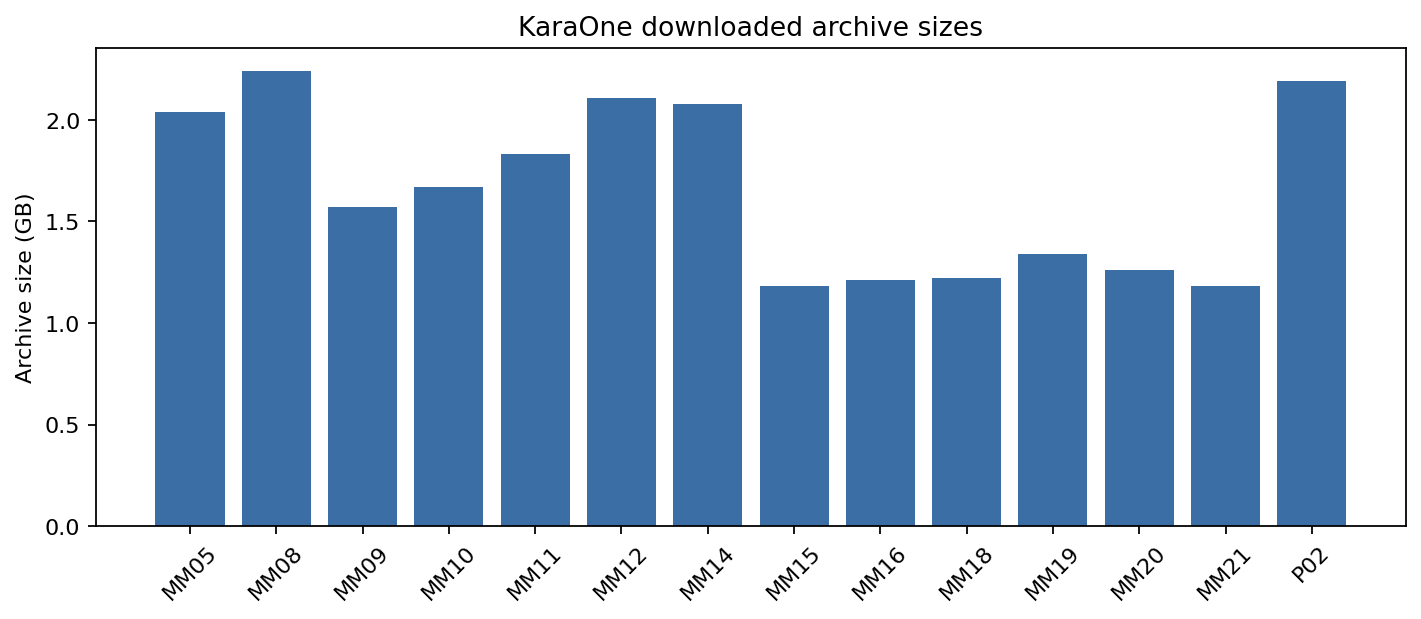

In [4]:
display(Image(filename=assets['archive_sizes']))

## 二、实验范式分析

In [5]:
interval_df = pd.DataFrame([
    ['clearing', summary['clearing_interval_count'], summary['clearing_duration_mean_sec']],
    ['thinking', summary['thinking_interval_count'], summary['thinking_duration_mean_sec']],
    ['stimulus_like', summary['stimulus_like_interval_count'], summary['stimulus_like_duration_mean_sec']],
    ['overt_like', summary['overt_like_interval_count'], summary['overt_like_duration_mean_sec']],
], columns=['interval_family', 'count', 'mean_duration_sec'])
display(interval_df)
display(Markdown('`epoch_inds.mat` 明确给出了 clearing / thinking / speaking-like 区间；结合标签与 wav，可以把 speaking-like 再拆成 stimulus-like 与 overt-like 两段。'))


,interval_family,count,mean_duration_sec
0,clearing,165,4.978442
1,thinking,165,4.949630
2,stimulus_like,165,2.008121
3,overt_like,165,2.354024


`epoch_inds.mat` 明确给出了 clearing / thinking / speaking-like 区间；结合标签与 wav，可以把 speaking-like 再拆成 stimulus-like 与 overt-like 两段。

## 三、单受试者深度分析

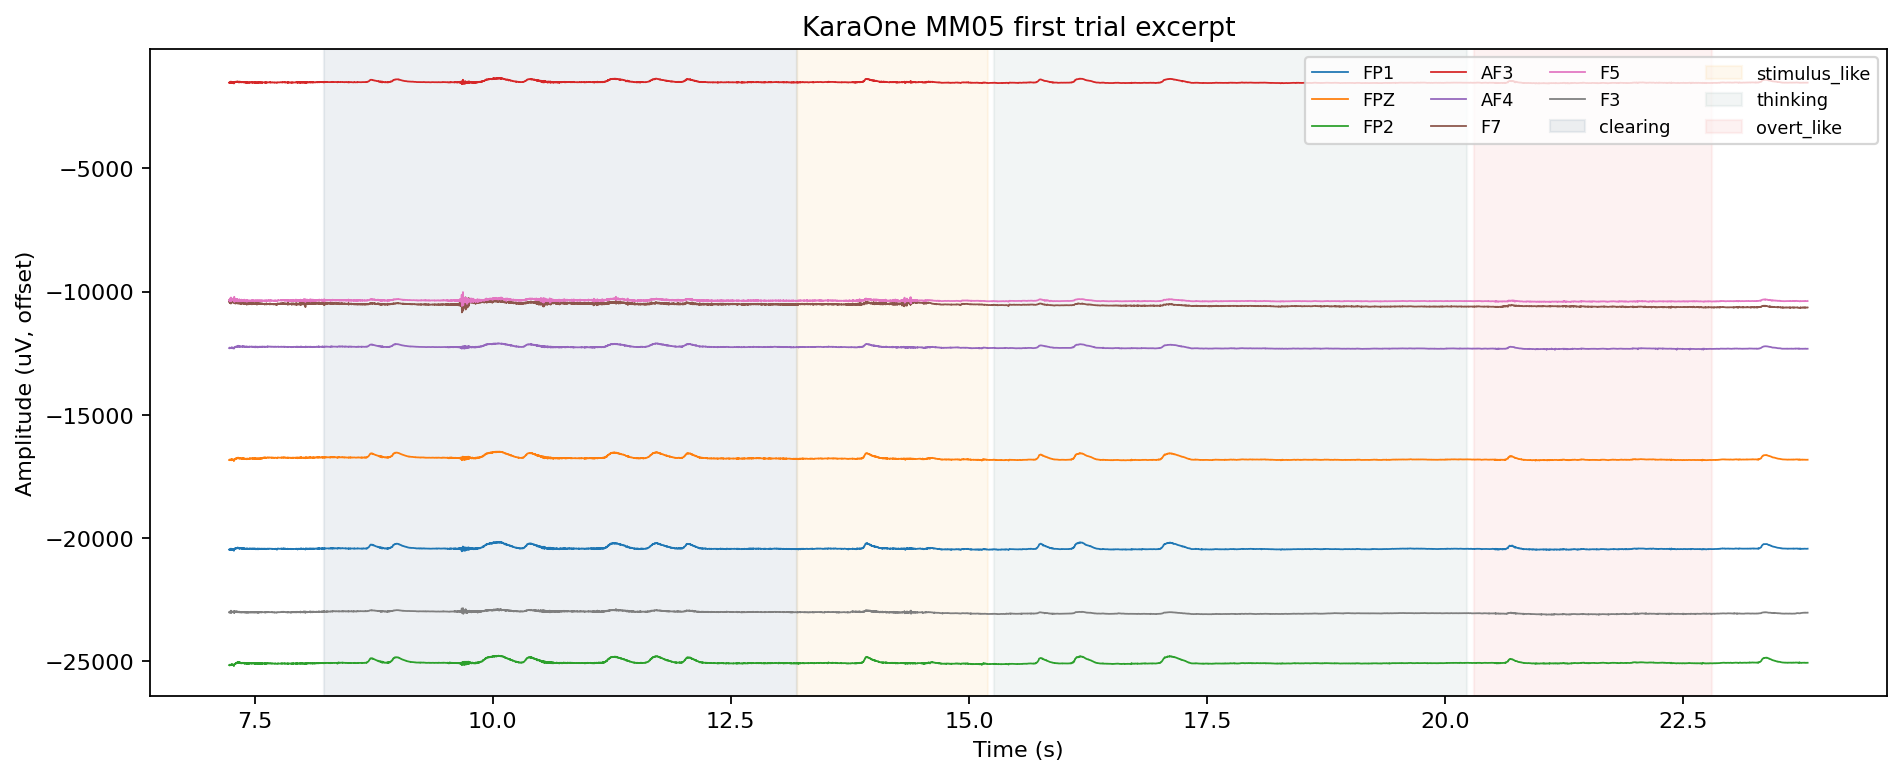

In [6]:
display(Image(filename=assets['waveform']))

clearing：清空上一 trial 的残留状态
thinking：在脑中默念/想象目标语音
stimulus-like：接收或确认当前 prompt
overt-like：真正说出该 prompt

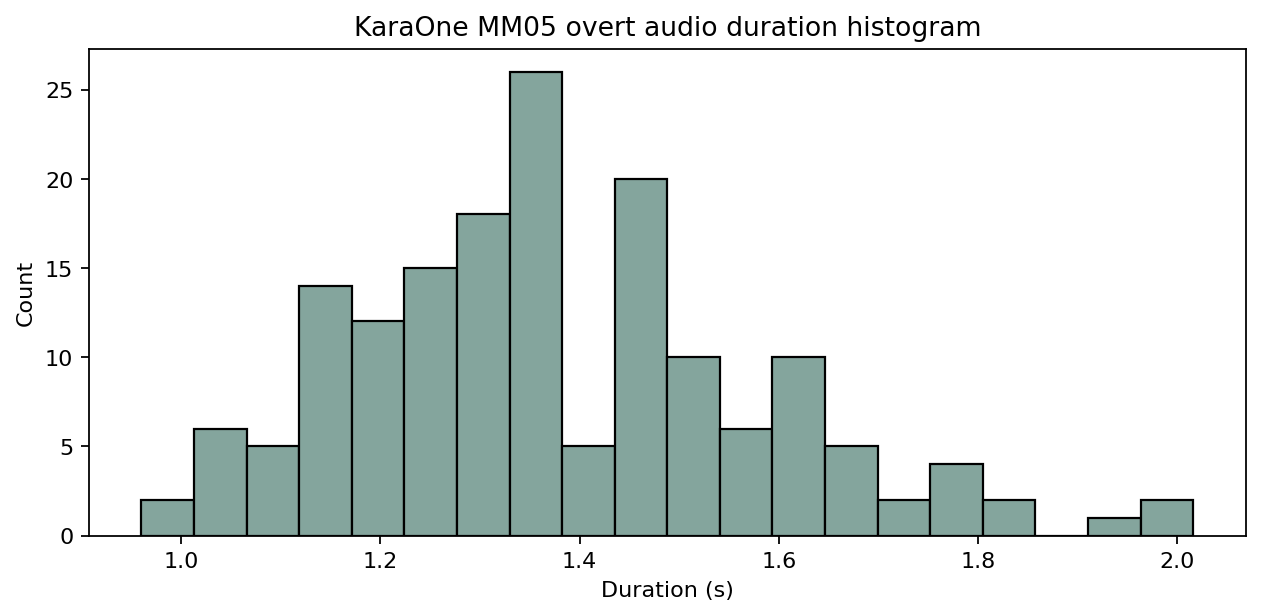

In [7]:
display(Image(filename=assets['audio_durations']))

## 四、事件与标签分析

,label,count
0,/diy/,15
1,/iy/,15
2,/m/,15
3,/n/,15
4,/piy/,15
5,/tiy/,15
6,/uw/,15
7,gnaw,15
8,knew,15
9,pat,15


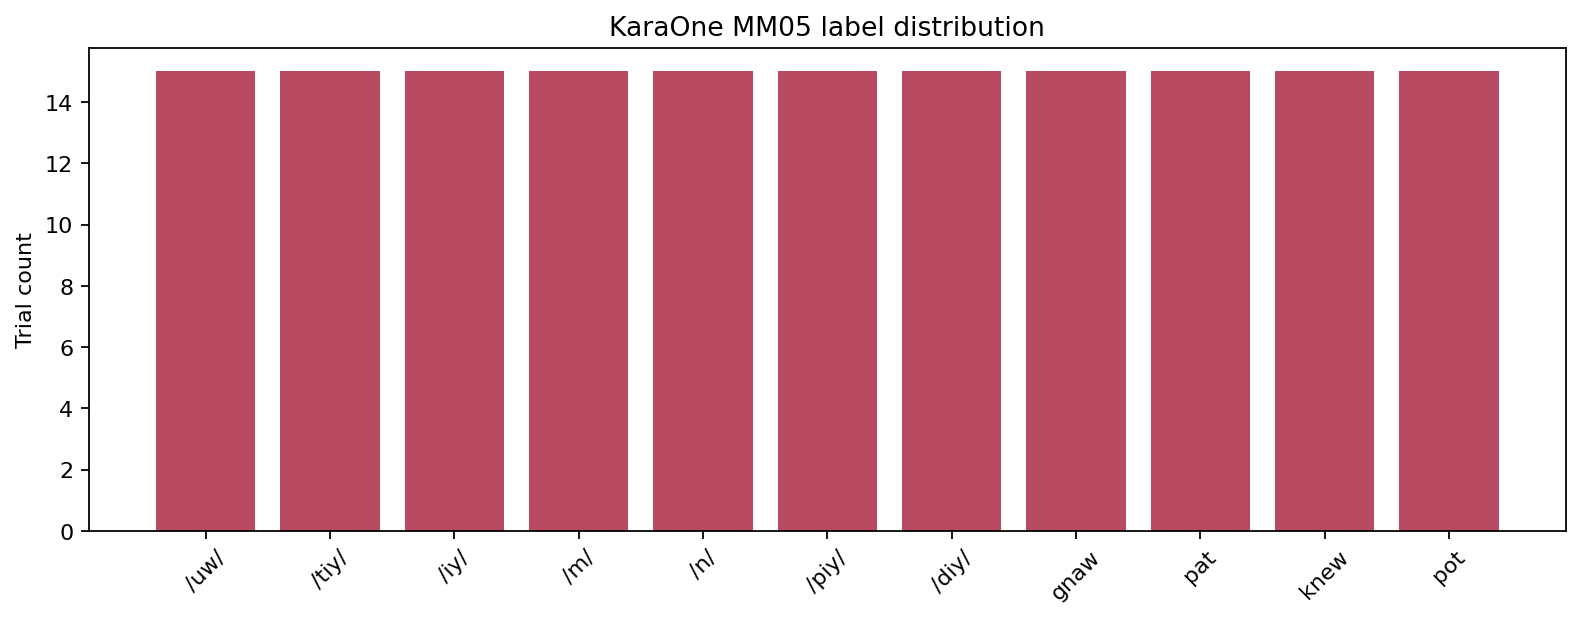

Trigger unique values observed via MNE: `[0.06553502048486844]`

In [8]:
label_df = pd.DataFrame(sorted(summary['representative_label_counter'].items()), columns=['label', 'count'])
display(label_df)
display(Image(filename=assets['labels']))
display(Markdown(f"Trigger unique values observed via MNE: `{summary['trigger_unique_values']}`"))


## 五、与研究目标的匹配度评估

In [9]:
fit_df = pd.DataFrame(summary['research_fit'].items(), columns=['task', 'judgment'])
display(fit_df)
for note in summary['data_quality_notes']:
    print('-', note)

print('\nKey conclusion: KaraOne is materially better than FEIS for overt-to-imagined transfer and for overt EEG -> acoustic representation studies, but it is still a small-vocabulary dataset.')


,task,judgment
0,phoneme_classification,Yes - strong fit at phonological/syllabic prom...
1,word_classification,Moderate - includes four words but vocabulary ...
2,speech_decoding,Yes - better than FEIS because EEG/audio/face ...
3,speech_reconstruction,Moderate foundation only


- epoch_inds.mat 是真正可用于 trial 对齐的关键信息源；MNE 读出的 Trigger 通道基本为常数，不能直接拿来做事件恢复。
- 单受试者同时具备原始 EEG、预处理特征、overt audio、face animation units，模态丰富度明显强于 FEIS。
- speaking_inds 数量是 330，而 labels 只有 165；数据自身显示每个 trial 对应两个 speaking-like 片段，较短者接近刺激呈现，较长者更像 overt speaking。

Key conclusion: KaraOne is materially better than FEIS for overt-to-imagined transfer and for overt EEG -> acoustic representation studies, but it is still a small-vocabulary dataset.
